In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import pandas as pd

## Task 1: Dataset Preparation

In [2]:
df = fetch_california_housing()
X = np.array(df.data)
Y = np.array(df.target).reshape(-1, 1)

print("feature shape", X.shape)
print("target shape", Y.shape)

feature shape (20640, 8)
target shape (20640, 1)


In [3]:
print("feature data")
print(pd.DataFrame(df.data[:10], columns=df.feature_names).round(2))

print("target values")
print(pd.DataFrame(Y[:10], columns=df.target_names).round(2))

feature data
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0    8.33      41.0      6.98       1.02       322.0      2.56     37.88   
1    8.30      21.0      6.24       0.97      2401.0      2.11     37.86   
2    7.26      52.0      8.29       1.07       496.0      2.80     37.85   
3    5.64      52.0      5.82       1.07       558.0      2.55     37.85   
4    3.85      52.0      6.28       1.08       565.0      2.18     37.85   
5    4.04      52.0      4.76       1.10       413.0      2.14     37.85   
6    3.66      52.0      4.93       0.95      1094.0      2.13     37.84   
7    3.12      52.0      4.80       1.06      1157.0      1.79     37.84   
8    2.08      42.0      4.29       1.12      1206.0      2.03     37.84   
9    3.69      52.0      4.97       0.99      1551.0      2.17     37.84   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
5    -122.25  
6    -122.25  
7    -122.25  
8    -122.26  


In [4]:
N = X.shape[0]

np.random.seed(9432)
indices = np.random.permutation(N)

# 60 - 20 - 20
train_end = int(0.6 * N)
val_end = int(0.8 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print("Train", X_train.shape, Y_train.shape)
print("Val", X_val.shape, Y_val.shape)
print("Test", X_test.shape, Y_test.shape)

Train (12384, 8) (12384, 1)
Val (4128, 8) (4128, 1)
Test (4128, 8) (4128, 1)


In [5]:
# Norm only through train for no data leakage
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std

print("new mean", X_train_norm.mean(axis=0))
print("new std", X_train_norm.std(axis=0))

new mean [ 6.67028520e-15 -4.05687721e-17 -1.97551946e-15 -9.56487359e-15
 -1.04742335e-16  1.83242942e-15  2.76463194e-14 -1.64395485e-13]
new std [1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
# Add a column of ones to as bias
def augment_features(X):
    ones_col = np.ones((X.shape[0], 1))
    return np.hstack([ones_col, X])

X_train_aug = augment_features(X_train_norm)
X_val_aug = augment_features(X_val_norm)
X_test_aug = augment_features(X_test_norm)

print("augmented train", X_train_aug.shape)
print("augmented val", X_val_aug.shape)
print("augmented test", X_test_aug.shape)

augmented train (12384, 9)
augmented val (4128, 9)
augmented test (4128, 9)


In [7]:
# again use only training data
target_mean = Y_train.mean()
target_std = Y_train.std()

Y_train_std = (Y_train - target_mean) / target_std
Y_val_std = (Y_val - target_mean) / target_std
Y_test_std = (Y_test - target_mean) / target_std

print("target mean", target_mean)
print("target std", target_std)

target mean 2.058294566375969
target std 1.1574139487531678


## Task 2: Implement Mini-Batch Gradient Descent


In [8]:
def loss(X, w, Y):
    # J(w) = (1/2N) * ||Xw - Y||^2

    N = X.shape[0]
    error = X @ w - Y

    loss = (1.0 / (2 * N)) * np.sum(error ** 2)
    return loss

def gradient(X_batch, w, Y_batch):
    # grad = (1/m) * X^T (Xw - Y)

    m = X_batch.shape[0]
    error = X_batch @ w - Y_batch

    grad = (1.0 / m) * (X_batch.T @ error)
    return grad

In [9]:
from threading import current_thread
def linear_regression(X_train, Y_train, X_val, Y_val, lr, batch_size=128, max=1000, patience=100):

    # best_w is weights corresponding to lowest validation loss
    # best_epoch is epoch number for lowest validation loss
    # train_loss_history is array of training loss per epoch (avg)
    # val_loss_history is array of validation loss per epoch

    M, N = X_train.shape
    w = np.zeros((N, 1))

    best_val_loss = np.inf
    best_w = w.copy()
    best_epoch = 0
    patience_cnt = 0

    train_loss_history = []
    val_loss_history = []

    for epoch in range(max):
        # shuffle
        curr = np.random.permutation(N)
        X_shuffled = X_train[curr]
        Y_shuffled = Y_train[curr]

        epoch_loss_sum = 0
        samples_seen = 0

        for start in range(0, N, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            Y_batch = Y_shuffled[start:end]
            m = X_batch.shape[0]

            # weight update
            grad = gradient(X_batch, w, Y_batch)
            w = w - lr * grad

            # loss
            batch_loss = loss(X_batch, w, Y_batch)
            epoch_loss_sum += batch_loss * m
            samples_seen += m

        # average training loss for the epoch
        epoch_train_loss = epoch_loss_sum / samples_seen
        train_loss_history.append(epoch_train_loss)

        # validation loss of the epoch
        epoch_val_loss = loss(X_val, w, Y_val)
        val_loss_history.append(epoch_val_loss)

        # Early stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_w = w.copy()
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_w, np.array(train_loss_history), np.array(val_loss_history), best_epoch

## Task 3: Effect of Learning Rate

Train the model using learning rates: $10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10$ with batch size = 128.

In [10]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

lr_results = {}  # store results per learning rate

for lr in learning_rates:

    np.random.seed(9432)

    w_opt, train_hist, val_hist, best_ep = linear_regression(
        X_train_aug, Y_train_std, X_val_aug, Y_val_std, lr
    )

    lr_results[lr] = {
        "w": w_opt,
        "train_hist": train_hist,
        "val_hist": val_hist,
        "best_epoch": best_ep,
        "best_val_loss": val_hist[best_ep]
    }
    print(f"LR = {lr:<8} | Epochs run = {len(train_hist):<5} | Best epoch = {best_ep:<5} | Best Val Loss = {val_hist[best_ep]:.5f}")

LR = 1e-05    | Epochs run = 1000  | Best epoch = 999   | Best Val Loss = 0.47940
LR = 0.0001   | Epochs run = 1000  | Best epoch = 999   | Best Val Loss = 0.45803
LR = 0.001    | Epochs run = 1000  | Best epoch = 999   | Best Val Loss = 0.40614
LR = 0.01     | Epochs run = 535   | Best epoch = 434   | Best Val Loss = 0.40027
LR = 0.1      | Epochs run = 145   | Best epoch = 44    | Best Val Loss = 0.40044
LR = 1        | Epochs run = 102   | Best epoch = 1     | Best Val Loss = 0.45336
LR = 10       | Epochs run = 101   | Best epoch = 0     | Best Val Loss = 30.53382


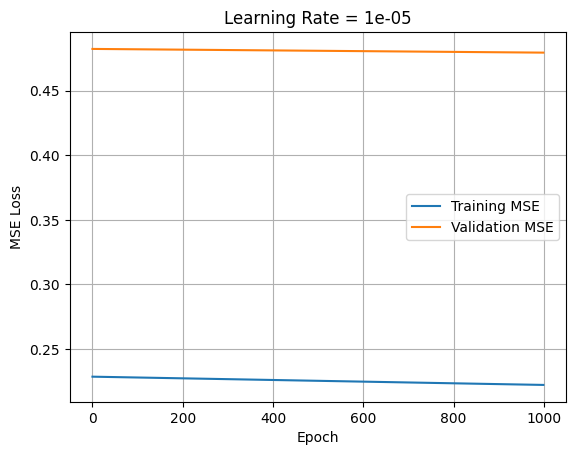

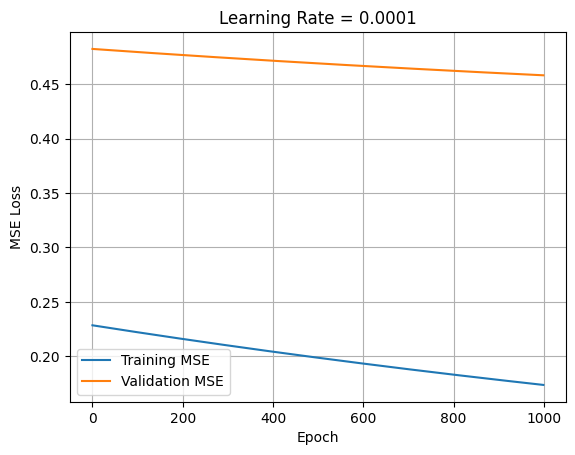

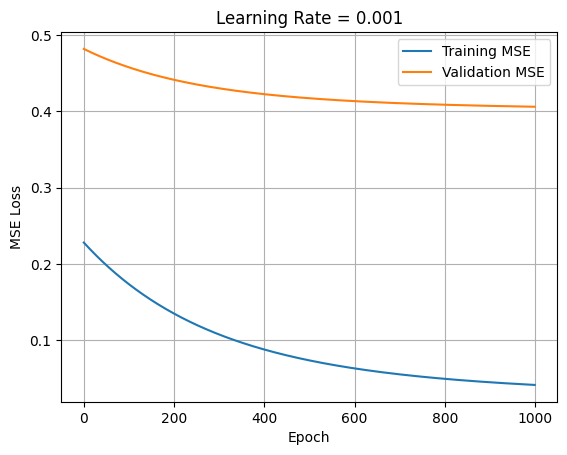

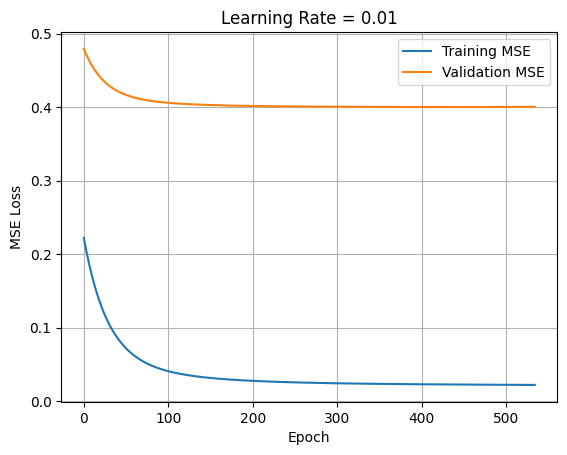

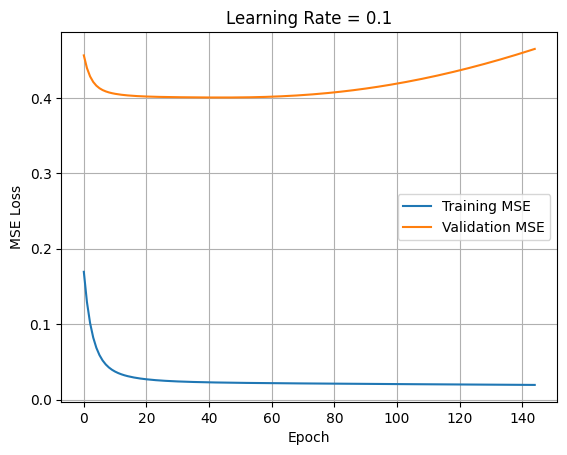

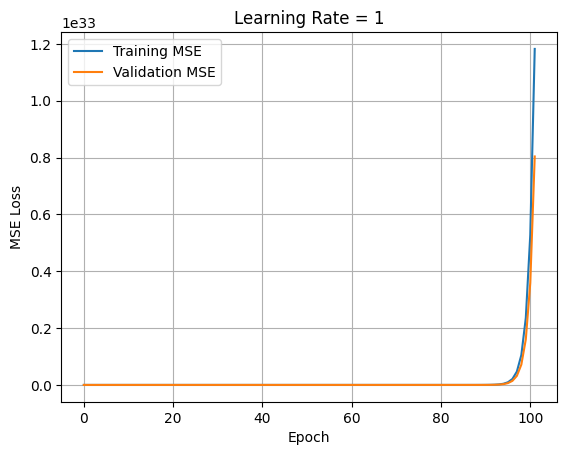

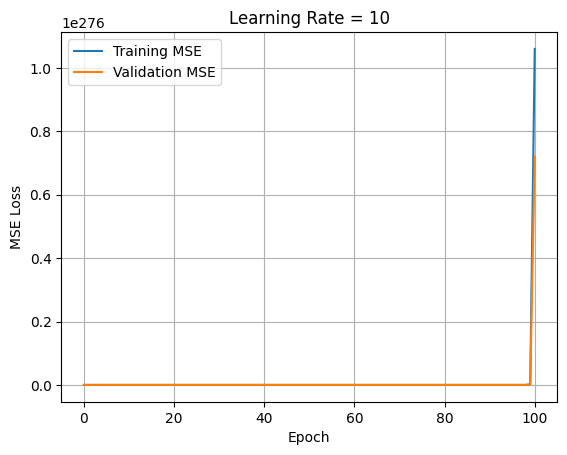

In [11]:
for lr in learning_rates:
    train_hist = lr_results[lr]["train_hist"]
    val_hist = lr_results[lr]["val_hist"]

    plt.plot(train_hist, label='Training MSE')
    plt.plot(val_hist, label='Validation MSE')
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Rate = {lr}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
best_lr = []
best_val_loss = np.inf

for lr in lr_results:
    if lr_results[lr]["best_val_loss"] < best_val_loss:
        best_val_loss = lr_results[lr]["best_val_loss"]
        best_lr = lr

print(f"Best learning rate: {best_lr}")
print(f"Minimum val loss: {best_val_loss}")

Best learning rate: 0.01
Minimum val loss: 0.40027218017188576


## Task 4: Effect of Batch Size

Using the best learning rate = 0.01 Experiment with the following batch sizes:
[ 1, 16, 32, 64, 128, 256, Entire Training Dataset ]

In [13]:
N_train = X_train_aug.shape[0]
batch_sizes = [1, 16, 32, 64, 128, 256, N_train]

bs_results = {}

for bs in batch_sizes:
    np.random.seed(9432)

    w_opt, train_hist, val_hist, best_ep = linear_regression(
        X_train_aug, Y_train_std, X_val_aug, Y_val_std,
        lr=best_lr, batch_size=bs
    )
    bs_results[bs] = {
        "w": w_opt,
        "train_hist": train_hist,
        "val_hist": val_hist,
        "best_epoch": best_ep,
        "best_val_loss": val_hist[best_ep]
    }

    label = "Full Batch" if bs == N_train else str(bs)
    print(f"Batch Size = {label:<12} | Epochs run = {len(train_hist):<5} | Best epoch = {best_ep:<5} | Best Val Loss = {val_hist[best_ep]:.5f}")

Batch Size = 1            | Epochs run = 142   | Best epoch = 41    | Best Val Loss = 0.40111
Batch Size = 16           | Epochs run = 535   | Best epoch = 434   | Best Val Loss = 0.40027
Batch Size = 32           | Epochs run = 535   | Best epoch = 434   | Best Val Loss = 0.40027
Batch Size = 64           | Epochs run = 535   | Best epoch = 434   | Best Val Loss = 0.40027
Batch Size = 128          | Epochs run = 535   | Best epoch = 434   | Best Val Loss = 0.40027
Batch Size = 256          | Epochs run = 535   | Best epoch = 434   | Best Val Loss = 0.40027
Batch Size = Full Batch   | Epochs run = 535   | Best epoch = 434   | Best Val Loss = 0.40027


In [14]:
table_rows = []
for bs in batch_sizes:
    label = "Entire Training Set" if bs == N_train else bs
    table_rows.append({
        "Batch Size": label,
        "Lowest Validation MSE": round(bs_results[bs]["best_val_loss"], 5),
        "Best Epoch": bs_results[bs]["best_epoch"]
    })

batch_size_summary_df = pd.DataFrame(table_rows)
batch_size_summary_df

,Batch Size,Lowest Validation MSE,Best Epoch
0,1,0.40111,41
1,16,0.40027,434
2,32,0.40027,434
3,64,0.40027,434
4,128,0.40027,434
5,256,0.40027,434
6,Entire Training Set,0.40027,434


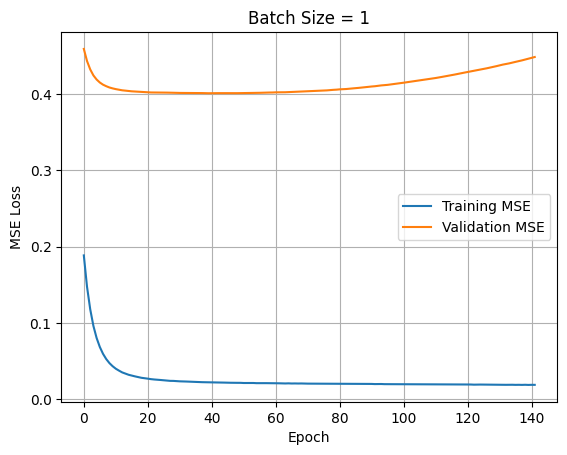

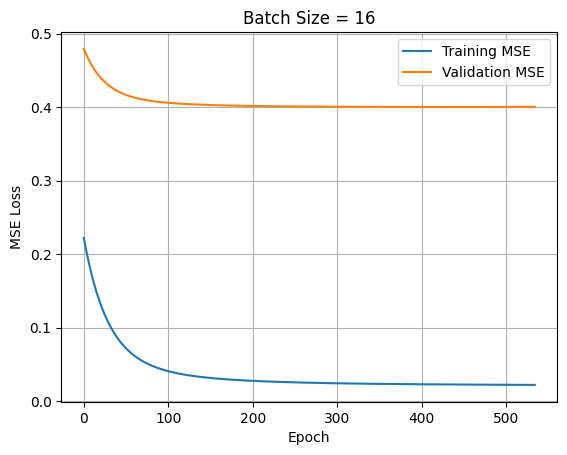

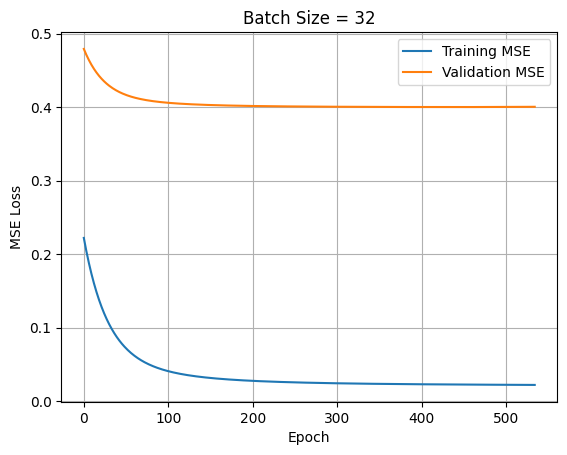

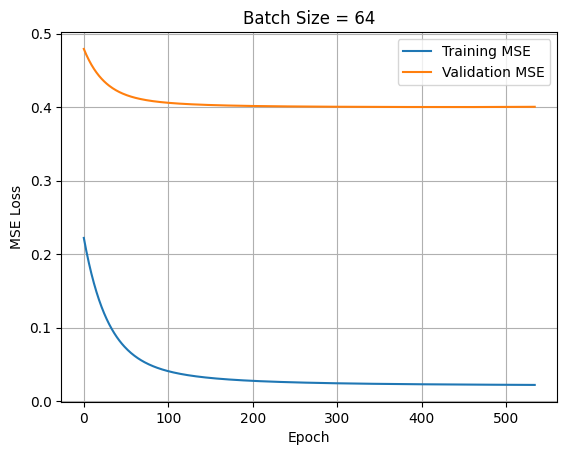

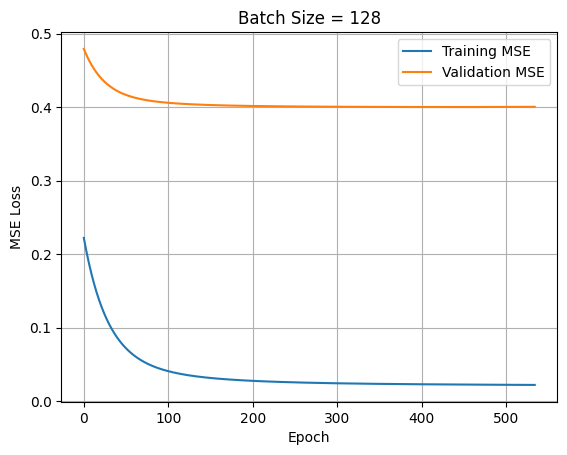

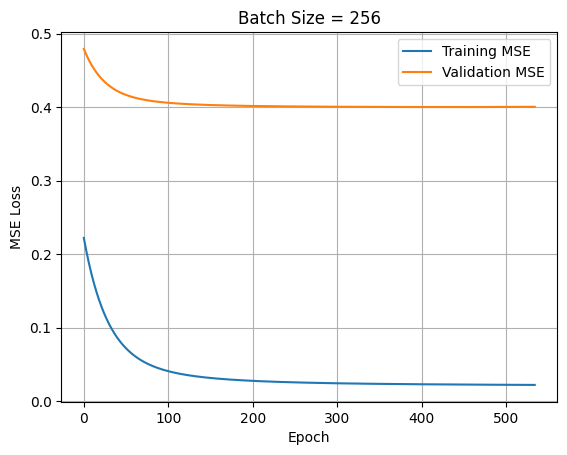

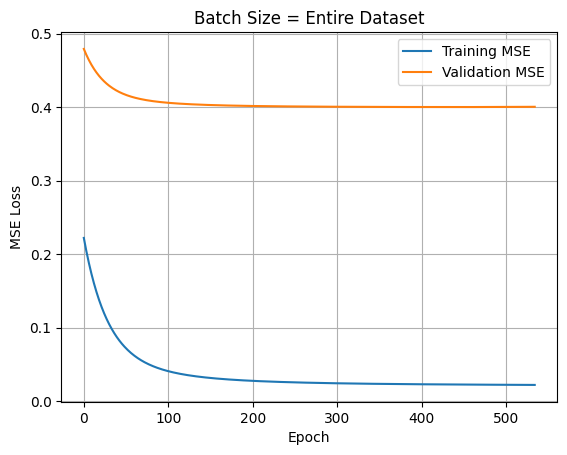

In [15]:
for bs in batch_sizes:
    train_hist = bs_results[bs]["train_hist"]
    val_hist = bs_results[bs]["val_hist"]
    label = "Entire Dataset" if bs == N_train else str(bs)

    plt.plot(train_hist, label='Training MSE')
    plt.plot(val_hist, label='Validation MSE')
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Batch Size = {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
best_bs = []
best_val_loss = np.inf

for bs in bs_results:
    if bs_results[bs]["best_val_loss"] < best_val_loss:
        best_val_loss = bs_results[bs]["best_val_loss"]
        best_bs = bs

print(f"Best batch size: {best_bs}")
print(f"Minimum val loss: {best_val_loss}")

Best batch size: 16
Minimum val loss: 0.40027218017188576


## Task 5: Inference on Test Set

Evaluation using the best model

In [17]:
final_w = bs_results[best_bs]["w"]
print("Final model weights:")
print(final_w)

Final model weights:
[[-0.13197572]
 [ 0.27784237]
 [ 0.07622846]
 [-0.05007245]
 [-0.27090342]
 [ 0.27849178]
 [-0.03666966]
 [-0.06839664]
 [-0.21814136]]


In [18]:
def compute_metrics(X_aug, Y_true_std, w, target_mean, target_std):

    Y_pred_std = X_aug @ w

    Y_pred = Y_pred_std * target_std + target_mean
    Y_true = Y_true_std * target_std + target_mean

    rmse = np.sqrt(mean_squared_error(Y_true, Y_pred))
    mae = mean_absolute_error(Y_true, Y_pred)
    mape = mean_absolute_percentage_error(Y_true, Y_pred) * 100
    r2 = r2_score(Y_true, Y_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R-squared": r2
    }, Y_pred, Y_true

In [19]:
train_metrics, Y_train_pred, Y_train_true = compute_metrics(X_train_aug, Y_train_std, final_w, target_mean, target_std)
val_metrics, Y_val_pred, Y_val_true = compute_metrics(X_val_aug, Y_val_std, final_w, target_mean, target_std)
test_metrics, Y_test_pred, Y_test_true = compute_metrics(X_test_aug, Y_test_std, final_w, target_mean, target_std)

metrics_df = pd.DataFrame({
    "Training": train_metrics,
    "Validation": val_metrics,
    "Test": test_metrics
})

metrics_df = metrics_df.round(5)
metrics_df

,Training,Validation,Test
RMSE,1.07182,1.03557,1.13942
MAE,0.77423,0.77180,0.79040
MAPE,47.34070,47.02539,46.56228
R-squared,0.14244,0.16994,0.03526


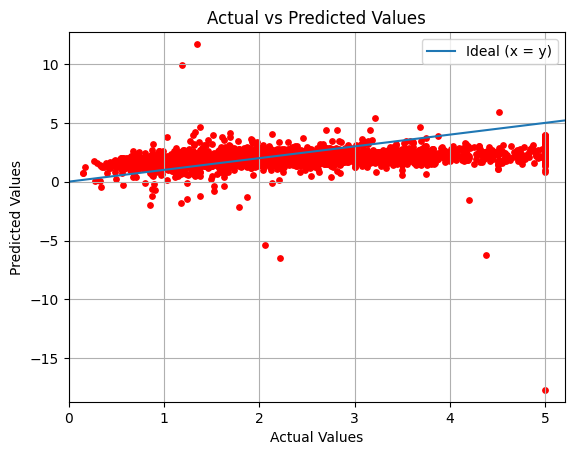

In [20]:

plt.scatter(Y_test_true, Y_test_pred, s=15, color='red')

# Reference line x = y
min_val = min(Y_test_true.min(), Y_test_pred.min())
max_val = max(Y_test_true.max(), Y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], label='Ideal (x = y)')
plt.xlim(0, 5.2)
plt.ylim(min_val - 1, max_val + 1)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()